# India STEM Education Loan Crisis Analysis

This notebook contains the complete data ingestion, cleaning, integration, and exploratory data analysis (EDA) pipeline for the Indian education loan ecosystem and its correlation with STEM student enrollment.

## Setup & Libraries

In [1]:
import os
import json
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2c3e50'
plt.rcParams['axes.labelcolor'] = '#2c3e50'
plt.rcParams['xtick.color'] = '#2c3e50'
plt.rcParams['ytick.color'] = '#2c3e50'

plots_dir = "plots"
os.makedirs(plots_dir, exist_ok=True)
print("Setup complete. Libraries imported and styled.")

Setup complete. Libraries imported and styled.


## Mappings & Constants

These dictionaries standardize misspelled or varying state names across different datasets and classify states into geographic regions.

In [2]:
STATE_STANDARDIZATION = {
    'Andaman & Nicobar Islands': 'Andaman and Nicobar Islands',
    'Andaman and Nicobar Islands': 'Andaman and Nicobar Islands',
    'Andhra Pradesh': 'Andhra Pradesh',
    'Arunachal Pradesh': 'Arunachal Pradesh',
    'Assam': 'Assam',
    'Bihar': 'Bihar',
    'Chandigarh': 'Chandigarh',
    'Chhattisgarh': 'Chhattisgarh',
    'Chhatisgarh': 'Chhattisgarh',
    'Dadra and Nagar Haveli and Daman and Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Delhi': 'Delhi',
    'Goa': 'Goa',
    'Gujarat': 'Gujarat',
    'Haryana': 'Haryana',
    'Himachal Pradesh': 'Himachal Pradesh',
    'Jammu and Kashmir': 'Jammu and Kashmir',
    'Jammu & Kashmir': 'Jammu and Kashmir',
    'Jharkhand': 'Jharkhand',
    'Karnataka': 'Karnataka',
    'Kerala': 'Kerala',
    'Ladakh': 'Ladakh',
    'Lakshadweep': 'Lakshadweep',
    'Madhya Pradesh': 'Madhya Pradesh',
    'Maharashtra': 'Maharashtra',
    'Manipur': 'Manipur',
    'Meghalaya': 'Meghalaya',
    'Mizoram': 'Mizoram',
    'Nagaland': 'Nagaland',
    'Odisha': 'Odisha',
    'Puducherry': 'Puducherry',
    'Punjab': 'Punjab',
    'Rajasthan': 'Rajasthan',
    'Sikkim': 'Sikkim',
    'Tamil Nadu': 'Tamil Nadu',
    'Telangana': 'Telangana',
    'Telengana': 'Telangana',
    'Tripura': 'Tripura',
    'Uttar Pradesh': 'Uttar Pradesh',
    'Uttarakhand': 'Uttarakhand',
    'Uttrakhand': 'Uttarakhand',
    'West Bengal': 'West Bengal'
}

REGION_MAPPING = {
    'Andaman and Nicobar Islands': 'South',
    'Andhra Pradesh': 'South',
    'Arunachal Pradesh': 'Northeast',
    'Assam': 'Northeast',
    'Bihar': 'East',
    'Chandigarh': 'North',
    'Chhattisgarh': 'Central',
    'Dadra and Nagar Haveli and Daman and Diu': 'West',
    'Delhi': 'North',
    'Goa': 'West',
    'Gujarat': 'West',
    'Haryana': 'North',
    'Himachal Pradesh': 'North',
    'Jammu and Kashmir': 'North',
    'Jharkhand': 'East',
    'Karnataka': 'South',
    'Kerala': 'South',
    'Ladakh': 'North',
    'Lakshadweep': 'South',
    'Madhya Pradesh': 'Central',
    'Maharashtra': 'West',
    'Manipur': 'Northeast',
    'Meghalaya': 'Northeast',
    'Mizoram': 'Northeast',
    'Nagaland': 'Northeast',
    'Odisha': 'East',
    'Puducherry': 'South',
    'Punjab': 'North',
    'Rajasthan': 'North',
    'Sikkim': 'Northeast',
    'Tamil Nadu': 'South',
    'Telangana': 'South',
    'Tripura': 'Northeast',
    'Uttar Pradesh': 'Central',
    'Uttarakhand': 'North',
    'West Bengal': 'East'
}
print("Mappings defined.")

Mappings defined.


## Phase 1: Data Cleaning, Integration, and Feature Engineering

Here we:
1. Load and clean state-wise disbursement data, reshaping it from wide to long format (State-Year combination).
2. Load and group outstanding loans data (as of 2021) by state.
3. Load and group STEM enrollment student count data by state.
4. Merge all datasets, handle missing values (NaNs), and engineer new metrics such as Average Loan Size, Growth Rate (from 2021-22 to 2023-24), and Female STEM percentage.
5. Export `summary_statistics.csv`.

In [3]:
df_disb_raw = pd.read_csv('dataset/RS_Session_262_AU_238_A_i.csv')
df_disb_raw = df_disb_raw[df_disb_raw['States/UT'].str.lower() != 'total']
df_disb_raw['State/UT'] = df_disb_raw['States/UT'].map(STATE_STANDARDIZATION)

unmapped_disb = df_disb_raw[df_disb_raw['State/UT'].isna()]
if len(unmapped_disb) > 0:
    print("WARNING: Unmapped states in disbursement file:", unmapped_disb['States/UT'].unique())

records = []
for idx, row in df_disb_raw.iterrows():
    state = row['State/UT']
    if pd.isna(state):
        continue
    records.append({
        'State/UT': state,
        'Year': '2021-22',
        'Accounts_Disbursed': int(round(row['2021-22 - Number of Account'])),
        'Amount_Disbursed_Crores': float(row['2021-22 - Amount Disbursed'])
    })
    records.append({
        'State/UT': state,
        'Year': '2022-23',
        'Accounts_Disbursed': int(round(row['2022-23 - Number of Account'])),
        'Amount_Disbursed_Crores': float(row['2022-23 - Amount Disbursed'])
    })
    records.append({
        'State/UT': state,
        'Year': '2023-24',
        'Accounts_Disbursed': int(round(row['2023-24 - Number of Account'])),
        'Amount_Disbursed_Crores': float(row['2023-24 - Amount Disbursed'])
    })
df_disb = pd.DataFrame(records)

df_out_raw = pd.read_csv('dataset/state_wise_outstanding_loans.csv')
df_out_raw['State/UT'] = df_out_raw['State/UT'].map(STATE_STANDARDIZATION)
df_out = df_out_raw.groupby('State/UT').agg({
    'Loan Accounts': 'sum',
    'Outstanding Amount (₹ Crores)': 'sum'
}).reset_index()
df_out.rename(columns={
    'Loan Accounts': 'Outstanding_Accounts_2021',
    'Outstanding Amount (₹ Crores)': 'Outstanding_Amount_Crores_2021'
}, inplace=True)

df_stem_raw = pd.read_csv('dataset/state_wise_stem_enrollment.csv')
df_stem_raw['State/UT'] = df_stem_raw['State/UT'].map(STATE_STANDARDIZATION)
df_stem = df_stem_raw.groupby('State/UT').agg({
    'STEM_Enrollment_Total': 'sum',
    'STEM_Enrollment_Female': 'sum',
    'STEM_Enrollment_Male': 'sum'
}).reset_index()

df_merged = pd.merge(df_disb, df_out, on='State/UT', how='left')
df_merged = pd.merge(df_merged, df_stem, on='State/UT', how='left')

df_merged['Region'] = df_merged['State/UT'].map(REGION_MAPPING)

df_merged['Outstanding_Accounts_2021'] = df_merged['Outstanding_Accounts_2021'].fillna(0)
df_merged['Outstanding_Amount_Crores_2021'] = df_merged['Outstanding_Amount_Crores_2021'].fillna(0)
df_merged['STEM_Enrollment_Total'] = df_merged['STEM_Enrollment_Total'].fillna(0)
df_merged['STEM_Enrollment_Female'] = df_merged['STEM_Enrollment_Female'].fillna(0)
df_merged['STEM_Enrollment_Male'] = df_merged['STEM_Enrollment_Male'].fillna(0)

df_merged['Average_Loan_Size_Lakhs'] = np.where(
    df_merged['Accounts_Disbursed'] > 0,
    (df_merged['Amount_Disbursed_Crores'] * 100) / df_merged['Accounts_Disbursed'],
    0
)
df_merged['STEM_Enrollment_Female_Pct'] = np.where(
    df_merged['STEM_Enrollment_Total'] > 0,
    (df_merged['STEM_Enrollment_Female'] / df_merged['STEM_Enrollment_Total']) * 100,
    0
)

df_growth = df_disb.pivot(index='State/UT', columns='Year', values='Amount_Disbursed_Crores')
df_growth['Growth_Rate_2021_to_2023_Pct'] = np.where(
    df_growth['2021-22'] > 0,
    ((df_growth['2023-24'] - df_growth['2021-22']) / df_growth['2021-22']) * 100,
    0
)
df_growth = df_growth.reset_index()[['State/UT', 'Growth_Rate_2021_to_2023_Pct']]
df_merged = pd.merge(df_merged, df_growth, on='State/UT', how='left')

df_merged.to_csv('summary_statistics.csv', index=False)
print("Merged Dataset head:")
df_merged.head()

Merged Dataset head:


,State/UT,Year,Accounts_Disbursed,Amount_Disbursed_Crores,Outstanding_Accounts_2021,Outstanding_Amount_Crores_2021,STEM_Enrollment_Total,STEM_Enrollment_Female,STEM_Enrollment_Male,Region,Average_Loan_Size_Lakhs,STEM_Enrollment_Female_Pct,Growth_Rate_2021_to_2023_Pct
0,Andaman and Nicobar Islands,2021-22,113,4.66,531,26.53,2067.0,1057.0,1010.0,South,4.123894,51.136913,-17.167382
1,Andaman and Nicobar Islands,2022-23,170,6.85,531,26.53,2067.0,1057.0,1010.0,South,4.029412,51.136913,-17.167382
2,Andaman and Nicobar Islands,2023-24,165,3.86,531,26.53,2067.0,1057.0,1010.0,South,2.339394,51.136913,-17.167382
3,Andhra Pradesh,2021-22,30429,1439.88,96434,6189.84,977006.0,422331.0,554675.0,South,4.731933,43.227063,59.588299
4,Andhra Pradesh,2022-23,67227,2779.33,96434,6189.84,977006.0,422331.0,554675.0,South,4.134247,43.227063,59.588299


## Phase 2: Exploratory Data Analysis & Visualizations

We'll generate the 10 data analyses. To focus on the latest available state-wise data, we'll slice the data for the fiscal year **2023-24** where appropriate.

### Analysis 1: Distribution of Loan Amounts Across States (Histogram & KDE)

Shows how loan disbursements are spread out across states/UTs.

/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/1590845310.py:8: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/1590845310.py:9: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('plots/analysis_1_loan_distribution.png', dpi=300)
/Users/vijay/Desktop/resumes/data(volvo)/Education Loan Crisis Analysis|/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


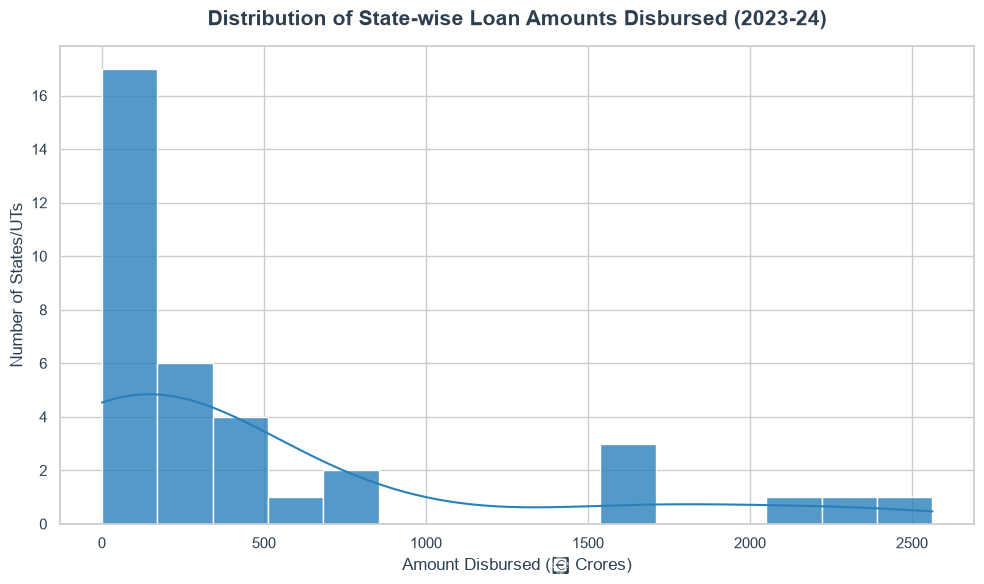

In [4]:
df_2023 = df_merged[df_merged['Year'] == '2023-24'].copy()

plt.figure(figsize=(10, 6))
sns.histplot(data=df_2023, x='Amount_Disbursed_Crores', kde=True, color='#2980B9', bins=15, alpha=0.8)
plt.title('Distribution of State-wise Loan Amounts Disbursed (2023-24)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Amount Disbursed (₹ Crores)', fontsize=12)
plt.ylabel('Number of States/UTs', fontsize=12)
plt.tight_layout()
plt.savefig('plots/analysis_1_loan_distribution.png', dpi=300)
plt.show()

### Analysis 2: Top 10 and Bottom 10 States by Loan Amount Disbursed

Compares the most-funded states against the least-funded states to show regional variance.

/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/3936945483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Amount_Disbursed_Crores', y='State/UT', ax=axes[0], palette='Blues_r')
/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/3936945483.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10, x='Amount_Disbursed_Crores', y='State/UT', ax=axes[1], palette='Oranges')
/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/3936945483.py:23: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/3936945483.py:24: UserW

/Users/vijay/Desktop/resumes/data(volvo)/Education Loan Crisis Analysis|/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


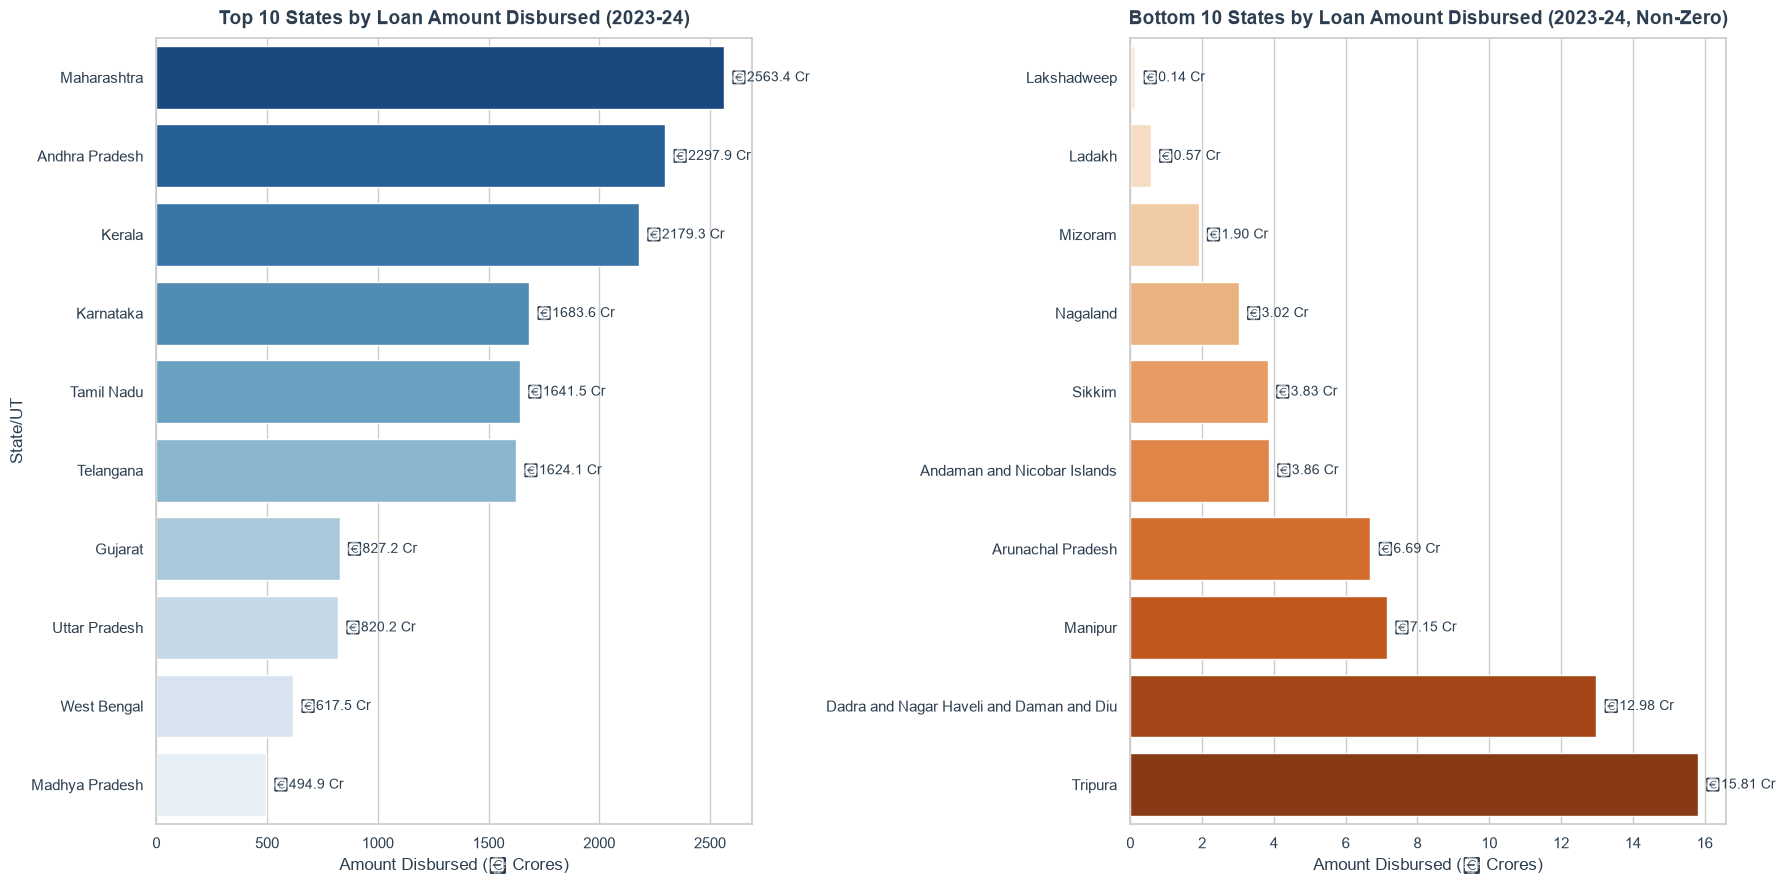

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

top_10 = df_2023.sort_values(by='Amount_Disbursed_Crores', ascending=False).head(10)
sns.barplot(data=top_10, x='Amount_Disbursed_Crores', y='State/UT', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 States by Loan Amount Disbursed (2023-24)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Amount Disbursed (₹ Crores)', fontsize=12)
axes[0].set_ylabel('State/UT', fontsize=12)

for p in axes[0].patches:
    axes[0].annotate(f"₹{p.get_width():.1f} Cr", (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

bottom_10 = df_2023[df_2023['Amount_Disbursed_Crores'] > 0].sort_values(by='Amount_Disbursed_Crores', ascending=True).head(10)
sns.barplot(data=bottom_10, x='Amount_Disbursed_Crores', y='State/UT', ax=axes[1], palette='Oranges')
axes[1].set_title('Bottom 10 States by Loan Amount Disbursed (2023-24, Non-Zero)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Amount Disbursed (₹ Crores)', fontsize=12)
axes[1].set_ylabel('', fontsize=12)

for p in axes[1].patches:
    axes[1].annotate(f"₹{p.get_width():.2f} Cr", (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.savefig('plots/analysis_2_top_bottom_states.png', dpi=300)
plt.show()

### Analysis 3: National YoY Education Loan Trend (2019-2024)

A dual-axis chart showing the number of loan accounts on the left and the total disbursement amount on the right.

/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/1015636431.py:25: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/1015636431.py:26: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('plots/analysis_3_national_yoy_trend.png', dpi=300)


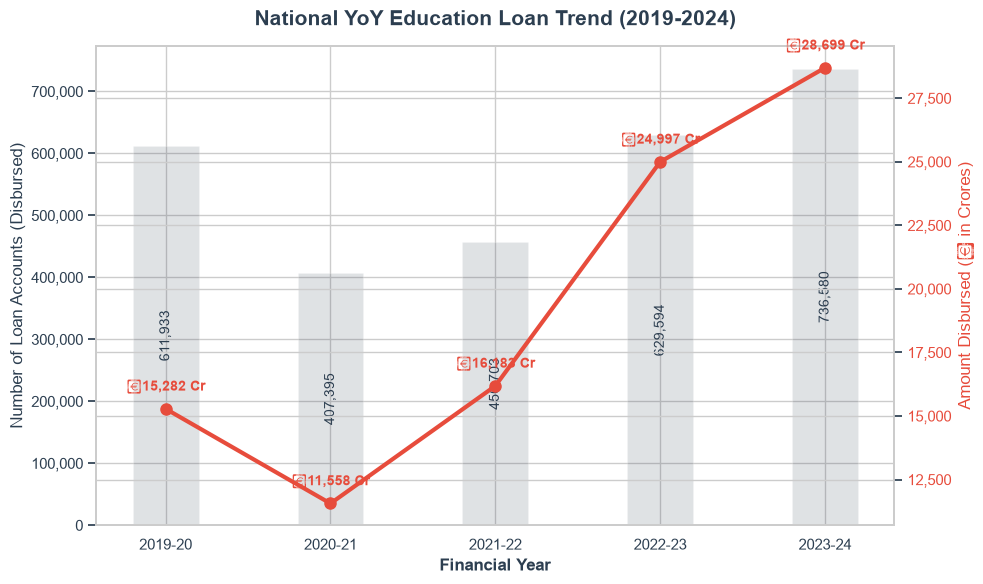

In [6]:
df_national = pd.read_csv('dataset/RS_Session_266_AU_2460_C_and_D.csv')

fig, ax1 = plt.subplots(figsize=(10, 6))
color1 = '#2C3E50'
ax1.set_xlabel('Financial Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Loan Accounts (Disbursed)', color=color1, fontsize=12)
bars = ax1.bar(df_national['Financial Year'], df_national['No. of Loan Accounts (Disbursed)'], color=color1, alpha=0.15, width=0.4, label='No. of Accounts')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

ax2 = ax1.twinx()
color2 = '#E74C3C'
ax2.set_ylabel('Amount Disbursed (₹ in Crores)', color=color2, fontsize=12)
ax2.plot(df_national['Financial Year'], df_national['Amount Disbursed (Rs. in Crore)'], color=color2, marker='o', linewidth=3, markersize=8, label='Amount Disbursed')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

for i, val in enumerate(df_national['Amount Disbursed (Rs. in Crore)']):
    ax2.text(i, val + 600, f'₹{val:,} Cr', ha='center', va='bottom', color=color2, fontweight='bold', fontsize=10)

for i, val in enumerate(df_national['No. of Loan Accounts (Disbursed)']):
    ax1.text(i, val/2, f'{val:,}', ha='center', va='center', color=color1, fontsize=10, rotation=90)

plt.title('National YoY Education Loan Trend (2019-2024)', fontsize=15, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('plots/analysis_3_national_yoy_trend.png', dpi=300)
plt.show()

### Analysis 4: YoY Loan Accounts and Amounts Disbursed by Bank Type

Compares Public Sector Banks (PSBs), Private Sector Banks, and Small Finance Banks.

/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/3540921715.py:23: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/3540921715.py:24: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('plots/analysis_4_bank_type_comparison.png', dpi=300)


/Users/vijay/Desktop/resumes/data(volvo)/Education Loan Crisis Analysis|/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


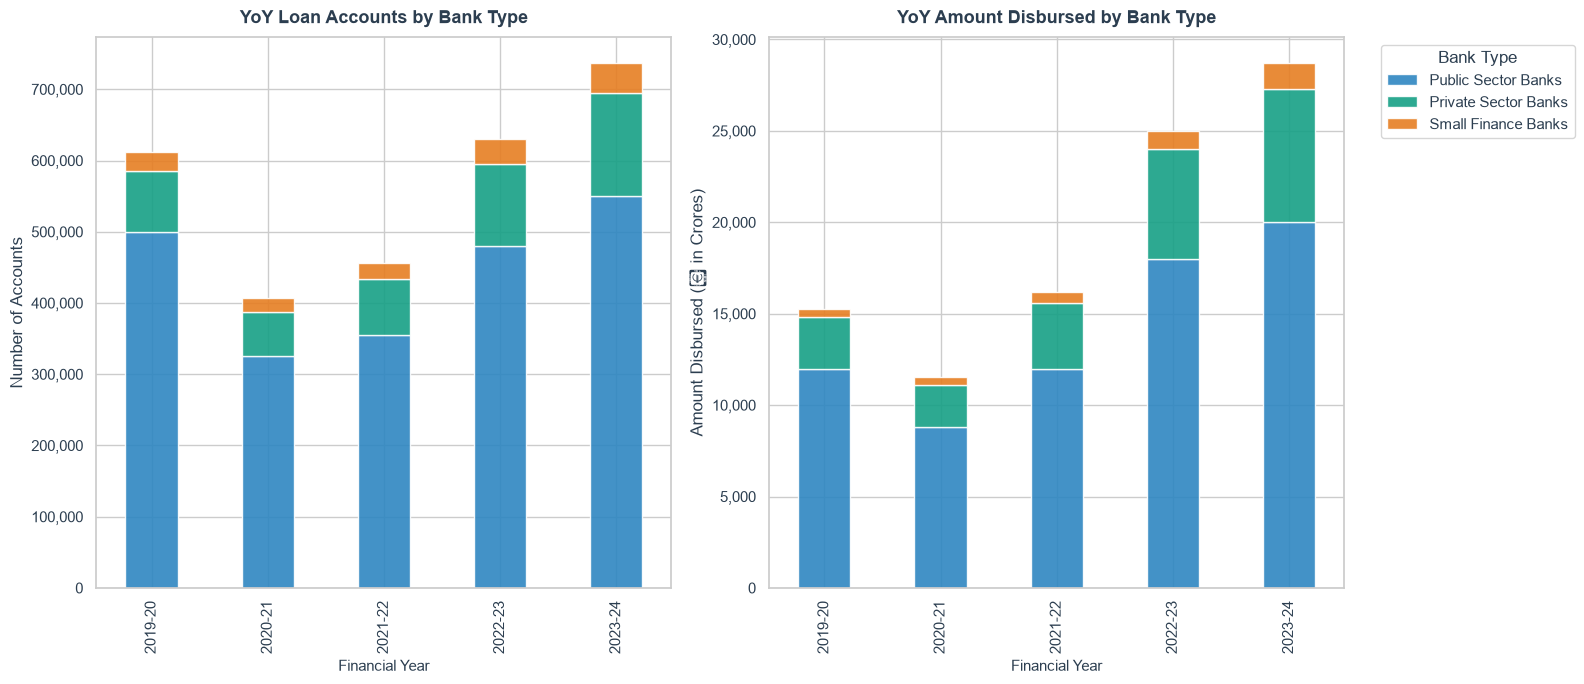

In [7]:
df_bank = pd.read_csv('dataset/bank_type_loans.csv')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
bank_colors = {'Public Sector Banks': '#2E86C1', 'Private Sector Banks': '#16A085', 'Small Finance Banks': '#E67E22'}

df_bank_acc = df_bank.pivot(index='Financial Year', columns='Bank Type', values='No. of Loan Accounts')
df_bank_acc = df_bank_acc[['Public Sector Banks', 'Private Sector Banks', 'Small Finance Banks']]
df_bank_acc.plot(kind='bar', stacked=True, ax=axes[0], color=[bank_colors[c] for c in df_bank_acc.columns], alpha=0.9, width=0.45)
axes[0].set_title('YoY Loan Accounts by Bank Type', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Number of Accounts', fontsize=12)
axes[0].set_xlabel('Financial Year', fontsize=11)
axes[0].legend().set_visible(False)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

df_bank_amt = df_bank.pivot(index='Financial Year', columns='Bank Type', values='Amount Disbursed (Rs. in Crore)')
df_bank_amt = df_bank_amt[['Public Sector Banks', 'Private Sector Banks', 'Small Finance Banks']]
df_bank_amt.plot(kind='bar', stacked=True, ax=axes[1], color=[bank_colors[c] for c in df_bank_amt.columns], alpha=0.9, width=0.45)
axes[1].set_title('YoY Amount Disbursed by Bank Type', fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylabel('Amount Disbursed (₹ in Crores)', fontsize=12)
axes[1].set_xlabel('Financial Year', fontsize=11)
axes[1].legend(title='Bank Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plots/analysis_4_bank_type_comparison.png', dpi=300)
plt.show()

### Analysis 5: State-wise Loan Growth Rate (2021-22 to 2023-24)

Bar chart showing growth rates by state (excluding states with zero initial loans).

/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/1819799369.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_growth_filtered, x='Growth_Rate_2021_to_2023_Pct', y='State/UT', palette='RdYlGn_r')


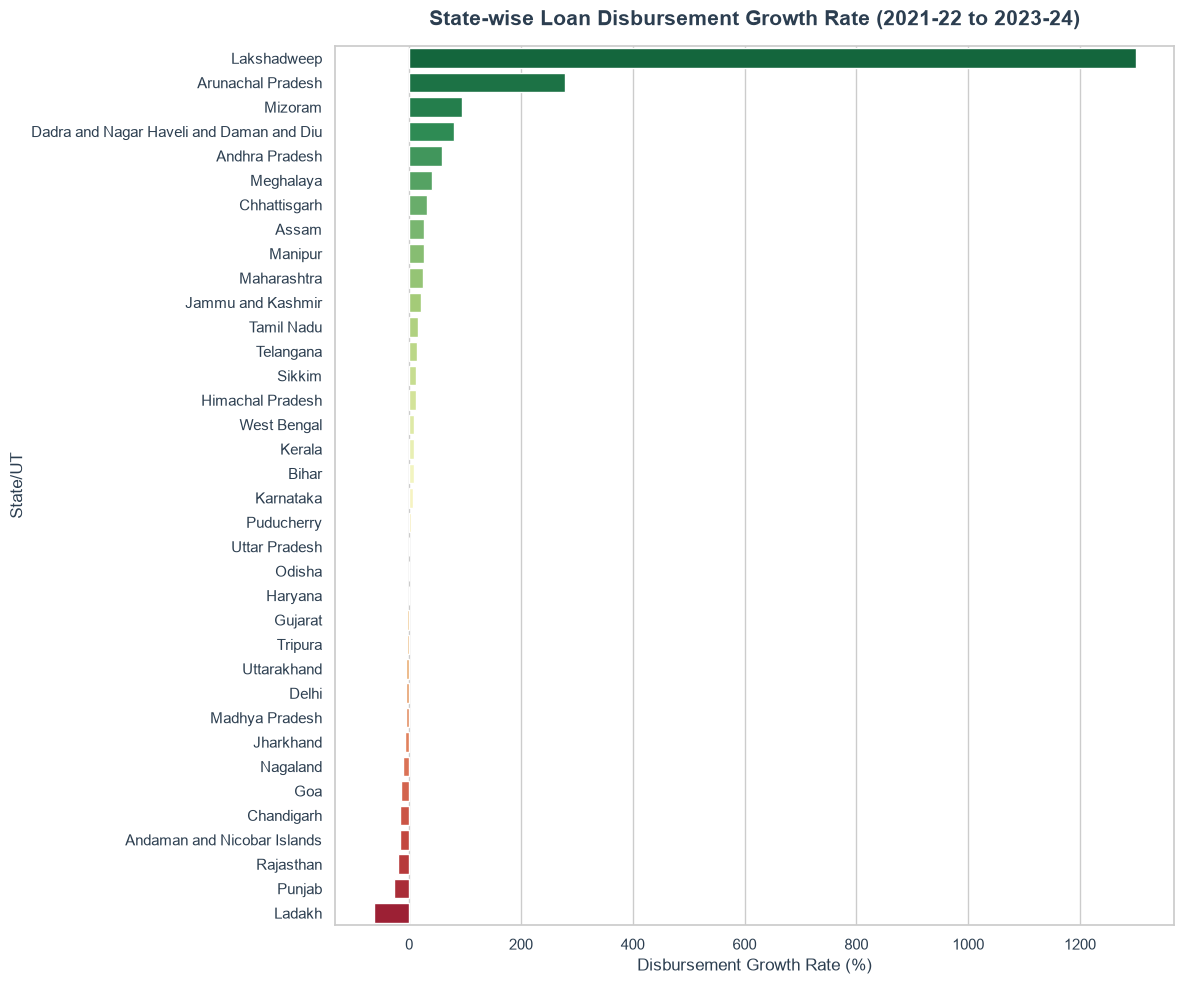

In [8]:
plt.figure(figsize=(12, 10))
df_growth_sorted = df_2023.dropna(subset=['Growth_Rate_2021_to_2023_Pct']).sort_values(by='Growth_Rate_2021_to_2023_Pct', ascending=False)
df_growth_filtered = df_growth_sorted[df_growth_sorted['Growth_Rate_2021_to_2023_Pct'] != 0]

sns.barplot(data=df_growth_filtered, x='Growth_Rate_2021_to_2023_Pct', y='State/UT', palette='RdYlGn_r')
plt.title('State-wise Loan Disbursement Growth Rate (2021-22 to 2023-24)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Disbursement Growth Rate (%)', fontsize=12)
plt.ylabel('State/UT', fontsize=12)
plt.tight_layout()
plt.savefig('plots/analysis_5_growth_rate_bar.png', dpi=300)
plt.show()

### Analysis 6: State-wise Loan Amount vs. Number of Accounts Disbursed

Scatter plot with a regression line to verify if higher volumes correlate directly with total loan amount, labeling outliers.

/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/2006454375.py:14: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
findfont: Failed to find font weight semibold, now using 700.


/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/2006454375.py:15: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('plots/analysis_6_amount_vs_accounts.png', dpi=300)


/Users/vijay/Desktop/resumes/data(volvo)/Education Loan Crisis Analysis|/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


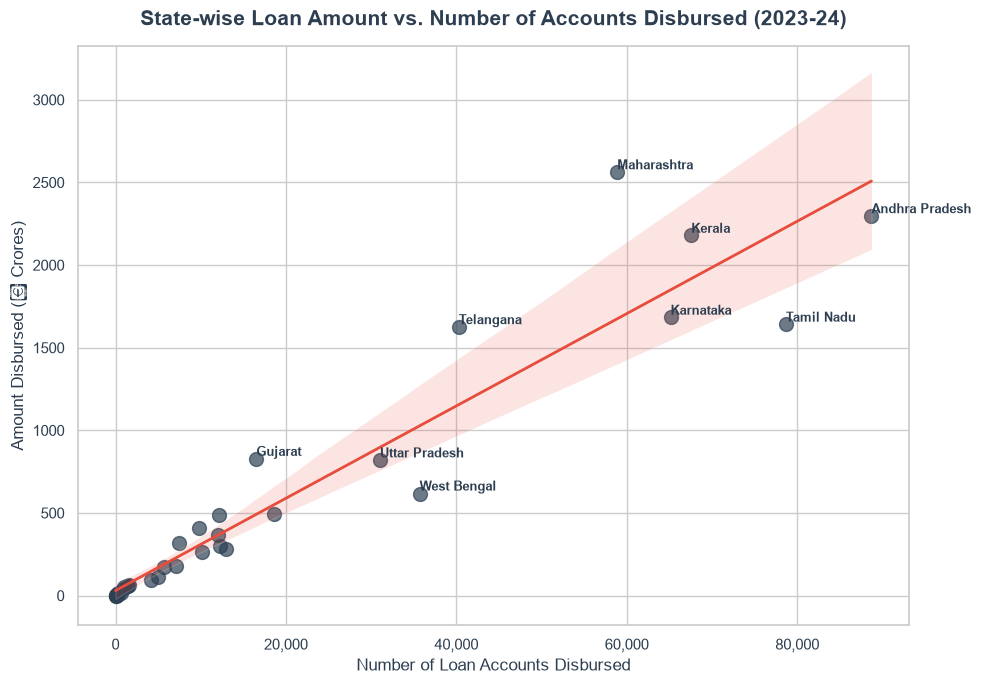

In [9]:
plt.figure(figsize=(10, 7))
sns.regplot(data=df_2023, x='Accounts_Disbursed', y='Amount_Disbursed_Crores', 
            scatter_kws={'s':100, 'alpha':0.7, 'color':'#2E4053'}, line_kws={'color':'#E74C3C', 'linewidth':2})

for idx, row in df_2023.iterrows():
    if row['Amount_Disbursed_Crores'] > 500 or row['Accounts_Disbursed'] > 20000:
        plt.text(row['Accounts_Disbursed'], row['Amount_Disbursed_Crores'], row['State/UT'],
                 fontsize=9, ha='left', va='bottom', color='#2C3E50', fontweight='semibold')

plt.title('State-wise Loan Amount vs. Number of Accounts Disbursed (2023-24)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Loan Accounts Disbursed', fontsize=12)
plt.ylabel('Amount Disbursed (₹ Crores)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('plots/analysis_6_amount_vs_accounts.png', dpi=300)
plt.show()

### Analysis 7: Gender Gap in STEM Student Enrollment by State

Diverging bar chart showing female enrollment vs. male enrollment in STEM courses by state.

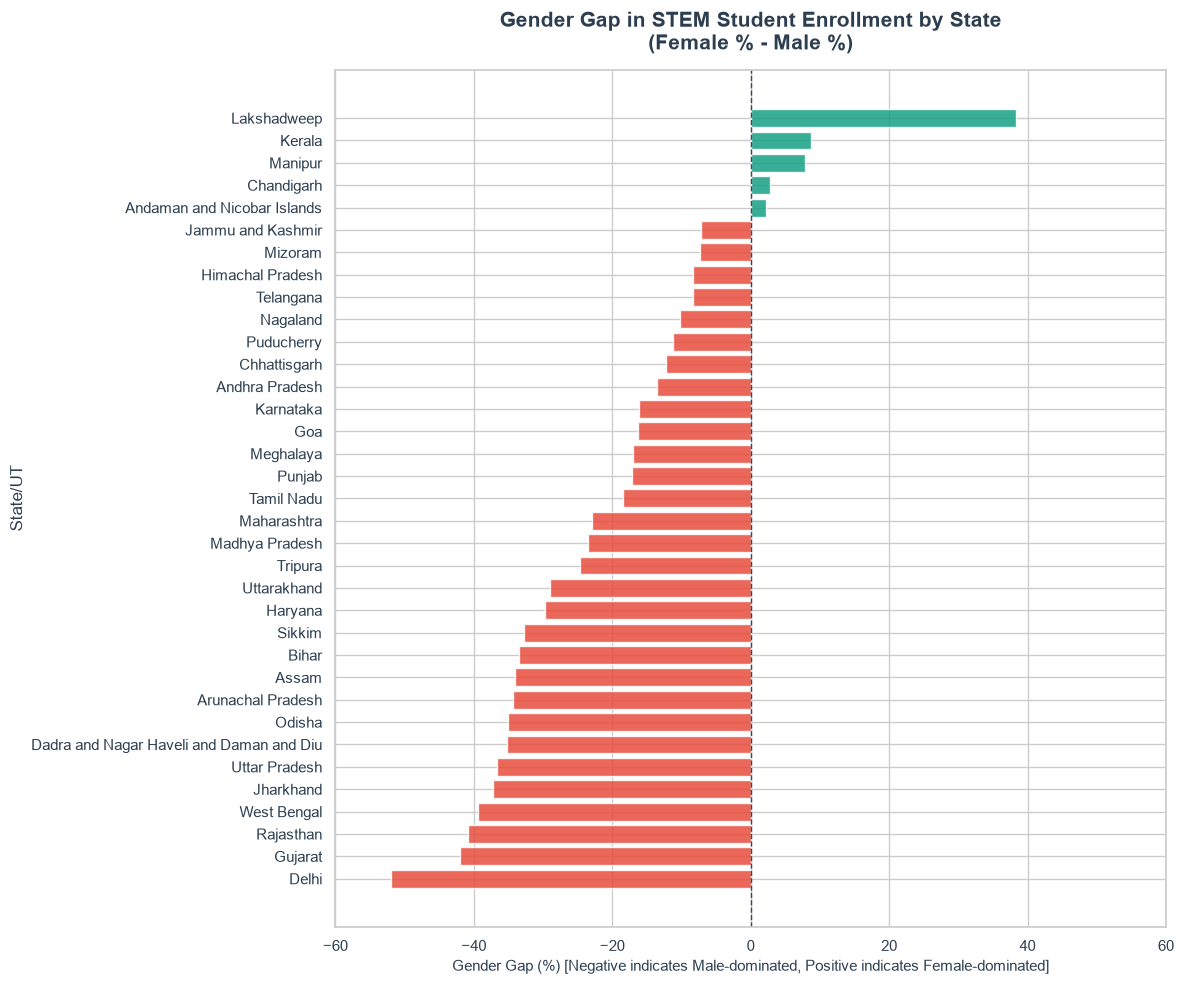

In [10]:
df_stem_gender = df_2023.dropna(subset=['STEM_Enrollment_Total']).copy()
df_stem_gender = df_stem_gender[df_stem_gender['STEM_Enrollment_Total'] > 0]
df_stem_gender['Gender_Gap_Pct'] = ((df_stem_gender['STEM_Enrollment_Female'] - df_stem_gender['STEM_Enrollment_Male']) / df_stem_gender['STEM_Enrollment_Total']) * 100
df_stem_gender = df_stem_gender.sort_values(by='Gender_Gap_Pct', ascending=True)

plt.figure(figsize=(12, 10))
colors = ['#E74C3C' if x < 0 else '#16A085' for x in df_stem_gender['Gender_Gap_Pct']]
plt.barh(df_stem_gender['State/UT'], df_stem_gender['Gender_Gap_Pct'], color=colors, alpha=0.85)
plt.axvline(0, color='#34495E', linewidth=1, linestyle='--')
plt.title('Gender Gap in STEM Student Enrollment by State\n(Female % - Male %)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Gender Gap (%) [Negative indicates Male-dominated, Positive indicates Female-dominated]', fontsize=11)
plt.ylabel('State/UT', fontsize=12)
plt.xlim(-60, 60)
plt.tight_layout()
plt.savefig('plots/analysis_7_gender_gap.png', dpi=300)
plt.show()

### Analysis 8: Loan Access vs. STEM Enrollment (Combined Bubble Chart)

Scatter plot where x = STEM enrollment, y = loan amount disbursed, bubble size = outstanding loan volume, and color = region.

/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/636372469.py:28: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/636372469.py:29: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('plots/analysis_8_loan_vs_stem_bubble.png', dpi=300)


/Users/vijay/Desktop/resumes/data(volvo)/Education Loan Crisis Analysis|/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


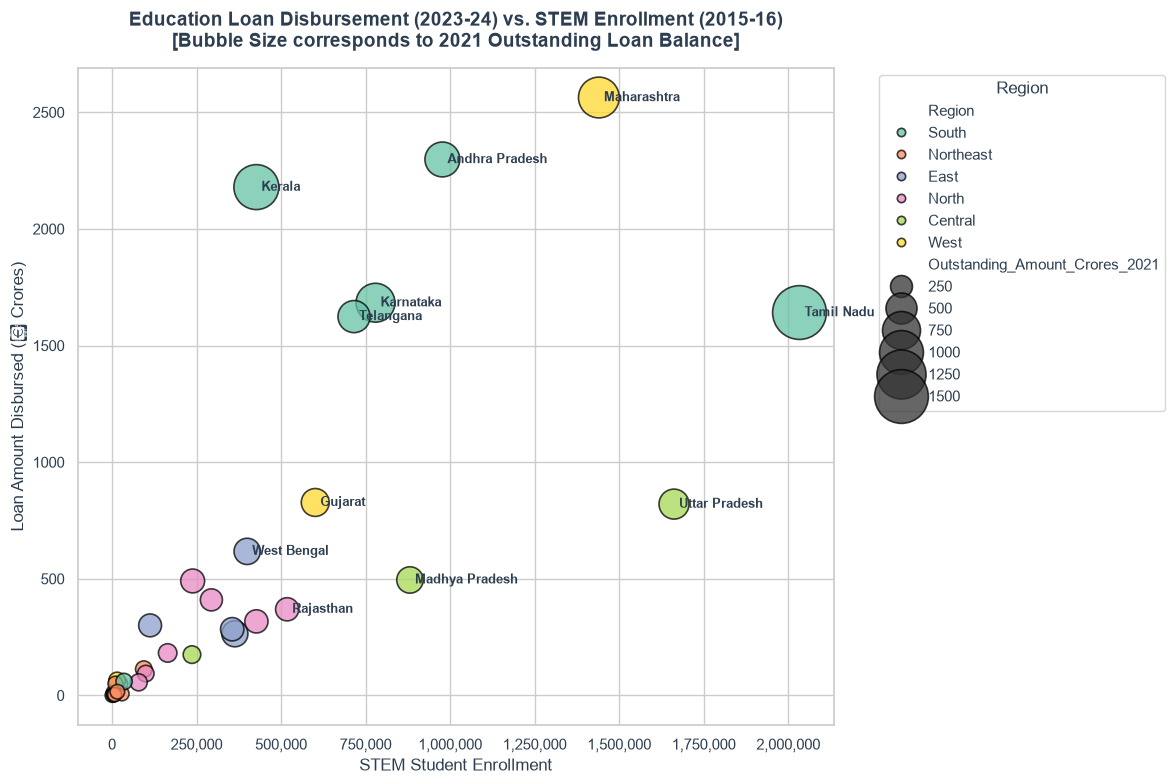

In [11]:
plt.figure(figsize=(12, 8))
bubble_weight = df_2023['Outstanding_Amount_Crores_2021'].fillna(0)
sizes = 100 + (bubble_weight / max(bubble_weight.max(), 1)) * 1400

scatter = sns.scatterplot(
    data=df_2023[df_2023['STEM_Enrollment_Total'] > 0],
    x='STEM_Enrollment_Total',
    y='Amount_Disbursed_Crores',
    size=sizes,
    hue='Region',
    sizes=(100, 1500),
    palette='Set2',
    alpha=0.75,
    edgecolor='black',
    linewidth=1.2
)

for idx, row in df_2023.iterrows():
    if row['Amount_Disbursed_Crores'] > 500 or row['STEM_Enrollment_Total'] > 500000:
        plt.text(row['STEM_Enrollment_Total'] + 15000, row['Amount_Disbursed_Crores'], row['State/UT'],
                 fontsize=9, ha='left', va='center', fontweight='semibold')

plt.title('Education Loan Disbursement (2023-24) vs. STEM Enrollment (2015-16)\n[Bubble Size corresponds to 2021 Outstanding Loan Balance]', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('STEM Student Enrollment', fontsize=12)
plt.ylabel('Loan Amount Disbursed (₹ Crores)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/analysis_8_loan_vs_stem_bubble.png', dpi=300)
plt.show()

### Analysis 9: State-wise Year Heatmap

Heatmap of loan disbursements (in ₹ Crores) across all states and fiscal years, sorted by total volume.

/Users/vijay/Desktop/resumes/data(volvo)/Education Loan Crisis Analysis|/venv/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.draw()


/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/3744114667.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/3744114667.py:11: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('plots/analysis_9_heatmap.png', dpi=300)


/Users/vijay/Desktop/resumes/data(volvo)/Education Loan Crisis Analysis|/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


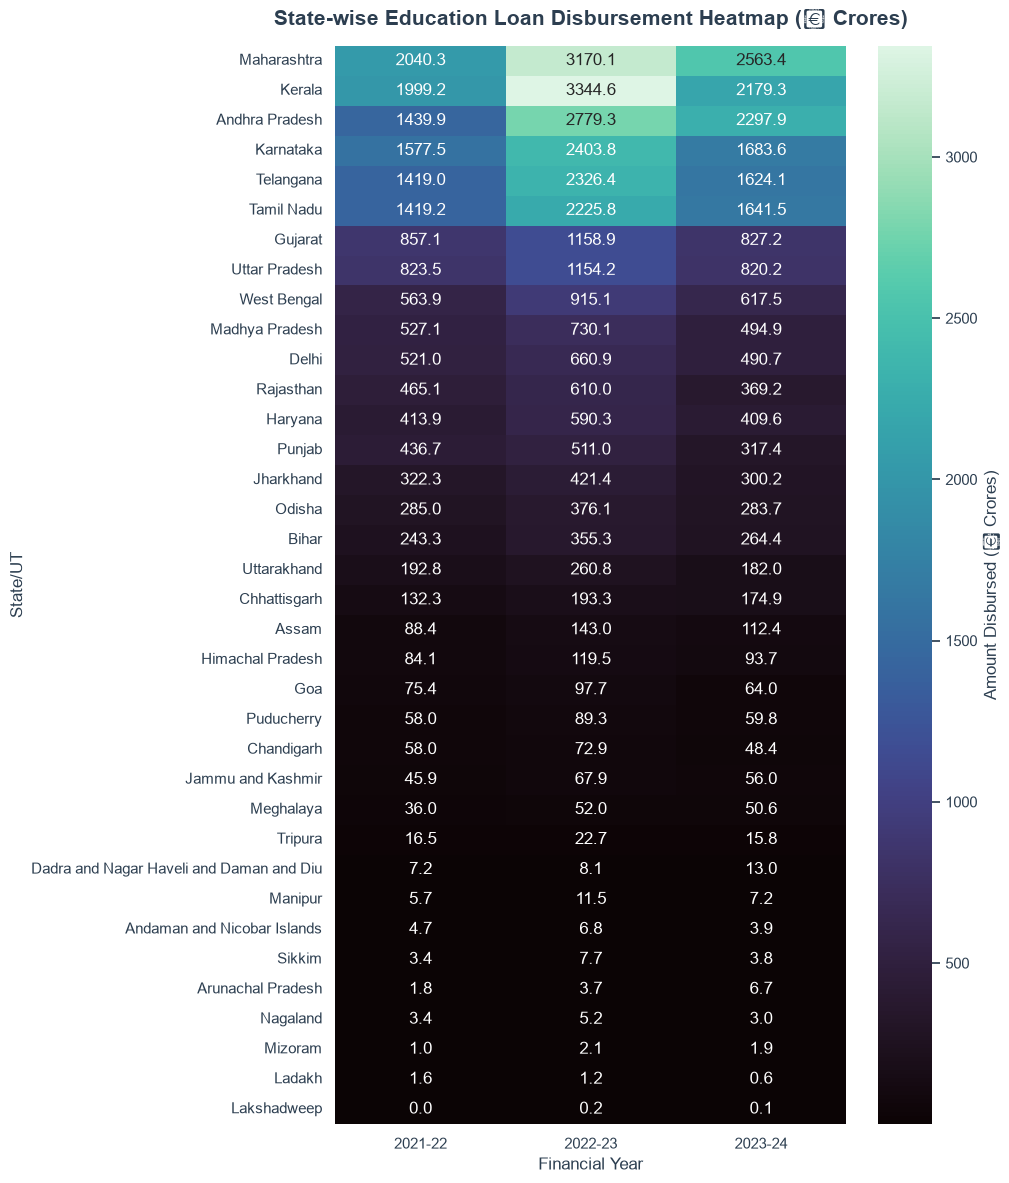

In [12]:
plt.figure(figsize=(10, 12))
df_pivot = df_merged.pivot(index='State/UT', columns='Year', values='Amount_Disbursed_Crores')
df_pivot['Total'] = df_pivot.sum(axis=1)
df_pivot_sorted = df_pivot.sort_values(by='Total', ascending=False).drop(columns='Total')

sns.heatmap(df_pivot_sorted, annot=True, fmt=".1f", cmap="mako", cbar_kws={'label': 'Amount Disbursed (₹ Crores)'})
plt.title('State-wise Education Loan Disbursement Heatmap (₹ Crores)', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('State/UT', fontsize=12)
plt.xlabel('Financial Year', fontsize=12)
plt.tight_layout()
plt.savefig('plots/analysis_9_heatmap.png', dpi=300)
plt.show()

### Analysis 10: Regional Distribution Boxplot

Boxplot and overlaid strip plots representing loan disbursement distributions across different geographical regions.

/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/1112932412.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_2023, x='Region', y='Amount_Disbursed_Crores', palette='Set2')
/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/1112932412.py:7: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y7/rvmmz7lx2w7ftg0bxtz00q2w0000gn/T/ipykernel_3024/1112932412.py:8: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('plots/analysis_10_boxplot_region.png', dpi=300)


/Users/vijay/Desktop/resumes/data(volvo)/Education Loan Crisis Analysis|/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


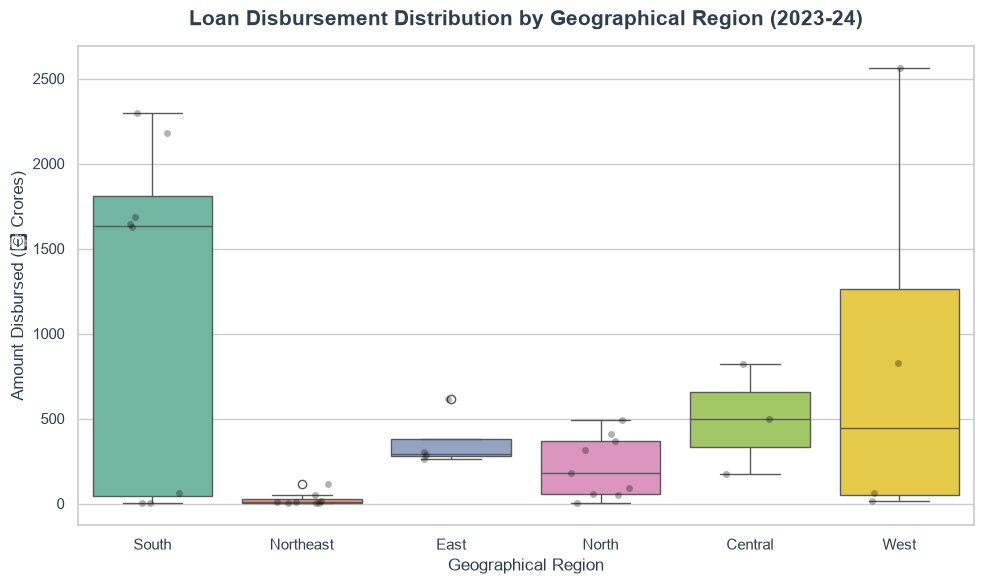

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_2023, x='Region', y='Amount_Disbursed_Crores', palette='Set2')
sns.stripplot(data=df_2023, x='Region', y='Amount_Disbursed_Crores', color='black', alpha=0.3, size=5, jitter=0.2)
plt.title('Loan Disbursement Distribution by Geographical Region (2023-24)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Geographical Region', fontsize=12)
plt.ylabel('Amount Disbursed (₹ Crores)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/analysis_10_boxplot_region.png', dpi=300)
plt.show()